# Analysis of sentences

## 1. Read data

In [1]:
import pandas as pd
sentence_df = pd.read_excel("..\\..\\dataset\\analysis_datasets\\translated_sentence_data.xlsx")

In [ ]:
# clean sentences as inputs
sentences = sentence_df["Clean_Sentence"].to_list()

## 2. Embed the lists of sentences with sentence-transformer multilingual-v1

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Precalculating multilingual embeddings
# embedding model 1
embedding_model_st_v1 = SentenceTransformer("distiluse-base-multilingual-cased-v1")

# run the following for embeddings if no pre-saved embeddings can be loaded
#embeddings_mv1 = embedding_model_st_v1.encode(sentences, show_progress_bar=True)
# save the pre-calculated embeddings 
#np.save('..\\..\\saved_models\\sentence_embeddings_transformers_nl.npy', embeddings_mv1)

c:\Users\p70092940\OneDrive - Maastricht University\Desktop\Projects\MyIBDcoach-NLP\mijnidbcoachnlp\.venv\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [ ]:
import numpy as np

# load pre-saved embeddings
embeddings = np.load("..\\..\\saved_models\\sentence_embeddings_transformers_nl.npy")

In [7]:
### Importing the list of Dutch stopwords

with open('..\\..\\dataset\\stopwords.txt', 'r') as file:
    lines = [line.strip() for line in file.readlines()]

dutch_stopwords = lines

extra_list = [
    'maandag', 'dinsdag', 'woensdag', 'donderdag', 'vrijdag', 'zaterdag', 'zondag',
    'januari', 'februari', 'maart', 'april', 'mei', 'juni', 'juli', 'augustus', 'september', 'oktober', 'november', 'december',
    'jan', 'feb', 'mrt', 'apr', 'mei', 'jun', 'jul', 'aug', 'sep', 'okt', 'nov', 'dec'
]

dutch_stopwords.extend(extra_list)

## 3. Preparations for fine-tuning

In [55]:
#generate a list of UMAP combinations
n_neighbors_values = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50] # we are aiming for strict clusters so the n_neighbors range is relatively small
n_components_values = [2, 3, 4, 5, 6, 7]

#generate a list of HDBSCAN combinations
min_cluster_size_values = [5, 10, 15, 20, 35, 50]
min_samples_values = [5, 10, 15, 20, 35, 50]


## 4. Model 1: Sentence Transformers Multilingual v1 + UMAP + HDBSCAN

### 4.1 Fine-Tuning Model 1 using intra-topic similarity as the metric

In [52]:
from sklearn.metrics.pairwise import cosine_similarity

def calculate_intra_topic_cosine_similarity(embeddings, topics):
    topic_similarities = []
    
    for topic in set(topics):
        if topic == -1:  # Skip the "outlier" topic
            continue
        
        # Get embeddings of documents in the current topic
        topic_embeddings = embeddings[np.array(topics) == topic]
        
        if len(topic_embeddings) < 2:
            continue  # Skip topics with a single document
        
        # Calculate cosine similarities and average them
        cosine_sim = cosine_similarity(topic_embeddings)
        avg_cosine_sim = cosine_sim[np.triu_indices_from(cosine_sim, k=1)].mean()
        
        topic_similarities.append(avg_cosine_sim)

    return topic_similarities

#### 4.1.1. Tuning n_neighbors

In [53]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
import matplotlib.pyplot as plt
import numpy as np

model_topic_similarities_nneighbors = []  # Initialize as a list to store each model's results

for n_neighbors in n_neighbors_values:

    
    topic_model = BERTopic(
        # Pipeline models
        embedding_model=embedding_model_st_v1,
        umap_model=UMAP(n_neighbors=n_neighbors, metric='cosine', random_state=42),
        hdbscan_model=HDBSCAN(metric='euclidean', cluster_selection_method='eom', prediction_data=True),
        vectorizer_model=CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 2), token_pattern=r'\b[a-zA-Z]{2,}\b'),

        # Hyperparameters
        nr_topics=100,
        top_n_words=10,
        verbose=True
    )

    # Train model
    topics, probs = topic_model.fit_transform(sentences, embeddings)
    topics = topic_model.get_document_info(sentences)["Topic"]
    
    # Compute intra-topic cosine similarity
    intra_topic_similarity = calculate_intra_topic_cosine_similarity(embeddings, topics)
    

    model_topic_similarities_nneighbors.append(intra_topic_similarity)

model_topic_similarities_nneighbors


2024-10-31 13:43:49,282 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-10-31 13:44:38,736 - BERTopic - Dimensionality - Completed ✓
2024-10-31 13:44:38,737 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-10-31 13:44:41,369 - BERTopic - Cluster - Completed ✓
2024-10-31 13:44:41,369 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-10-31 13:44:43,451 - BERTopic - Representation - Completed ✓
2024-10-31 13:44:43,455 - BERTopic - Topic reduction - Reducing number of topics
2024-10-31 13:44:44,751 - BERTopic - Topic reduction - Reduced number of topics from 1681 to 100
2024-10-31 13:44:46,376 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-10-31 13:45:38,093 - BERTopic - Dimensionality - Completed ✓
2024-10-31 13:45:38,093 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-10-31 13:45:40,526 - BERTopic - Cluster - Completed ✓
2024-10-31 13:4

[[0.2537546,
  0.37117547,
  0.4811913,
  0.2079598,
  0.15273537,
  0.21772784,
  0.2965536,
  0.2170435,
  0.23130123,
  0.19217479,
  0.2165684,
  0.48585027,
  0.20853879,
  0.3021373,
  0.26700732,
  0.2538617,
  0.1553849,
  0.27959976,
  0.34405822,
  0.2633407,
  0.1931662,
  0.32254532,
  0.174842,
  0.39924812,
  0.2589245,
  0.41983432,
  0.3462049,
  0.21492973,
  0.25121802,
  0.23994245,
  0.3503804,
  0.33133435,
  0.31392187,
  0.2720553,
  0.42500246,
  0.40583062,
  0.30146074,
  0.24540013,
  0.27032188,
  0.26293522,
  0.30313113,
  0.40433478,
  0.34391776,
  0.32953992,
  0.17544587,
  0.33417228,
  0.35144052,
  0.48041752,
  0.41410315,
  0.35044023,
  0.5059005,
  0.2468708,
  0.23359074,
  0.46766898,
  0.32956833,
  0.4002578,
  0.37535858,
  0.4783278,
  0.20860443,
  0.3953027,
  0.4457877,
  0.35080975,
  0.38467526,
  0.65054476,
  0.4302688,
  0.29794022,
  0.3739439,
  0.31024426,
  0.21235521,
  0.2788686,
  0.4715765,
  0.4096572,
  0.18813598,
  0.33

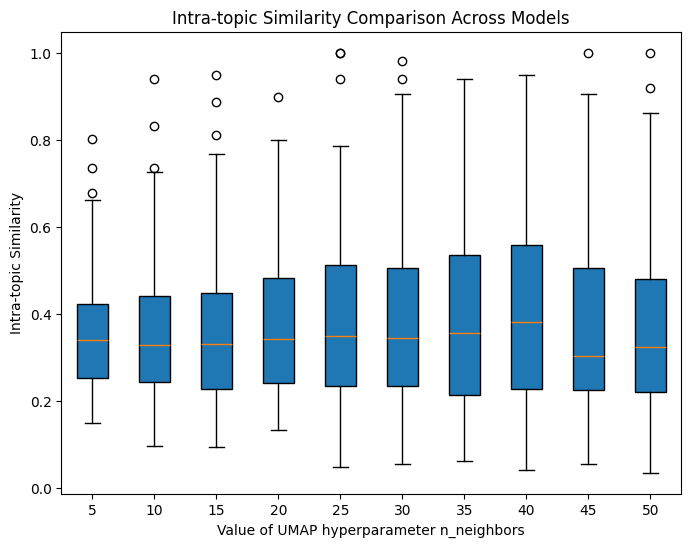

In [54]:
# Print the results
# Prepare data for plotting
data = model_topic_similarities_nneighbors

# Customizing the plot
# Plot boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(data, patch_artist=True)
plt.xticks(range(1, len(data) + 1), n_neighbors_values)  # Dynamically set labels
plt.xlabel("Value of UMAP hyperparameter n_neighbors")
plt.ylabel("Intra-topic Similarity")
plt.title("Intra-topic Similarity Comparison Across Models")
plt.show()

#### 4.1.2. Tuning n_components

In [56]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
import matplotlib.pyplot as plt
import numpy as np

model_topic_similarities_ncomponents = []  # Initialize as a list to store each model's results

for n_components in n_components_values:

    
    topic_model = BERTopic(
        # Pipeline models
        embedding_model=embedding_model_st_v1,
        umap_model=UMAP(n_neighbors=40, n_components=n_components, metric='cosine', random_state=42),
        hdbscan_model=HDBSCAN(metric='euclidean', cluster_selection_method='eom', prediction_data=True),
        vectorizer_model=CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 2), token_pattern=r'\b[a-zA-Z]{2,}\b'),

        # Hyperparameters
        nr_topics=100,
        top_n_words=10,
        verbose=True
    )

    # Train model
    topics, probs = topic_model.fit_transform(sentences, embeddings)
    topics = topic_model.get_document_info(sentences)["Topic"]
    
    # Compute intra-topic cosine similarity
    intra_topic_similarity = calculate_intra_topic_cosine_similarity(embeddings, topics)
    

    model_topic_similarities_ncomponents.append(intra_topic_similarity)


2024-10-31 14:00:20,063 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-10-31 14:01:36,312 - BERTopic - Dimensionality - Completed ✓
2024-10-31 14:01:36,312 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-10-31 14:01:38,089 - BERTopic - Cluster - Completed ✓
2024-10-31 14:01:38,089 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-10-31 14:01:39,673 - BERTopic - Representation - Completed ✓
2024-10-31 14:01:39,676 - BERTopic - Topic reduction - Reducing number of topics
2024-10-31 14:01:40,775 - BERTopic - Topic reduction - Reduced number of topics from 1390 to 100
2024-10-31 14:01:41,893 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-10-31 14:02:59,063 - BERTopic - Dimensionality - Completed ✓
2024-10-31 14:02:59,063 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-10-31 14:03:00,928 - BERTopic - Cluster - Completed ✓
2024-10-31 14:0

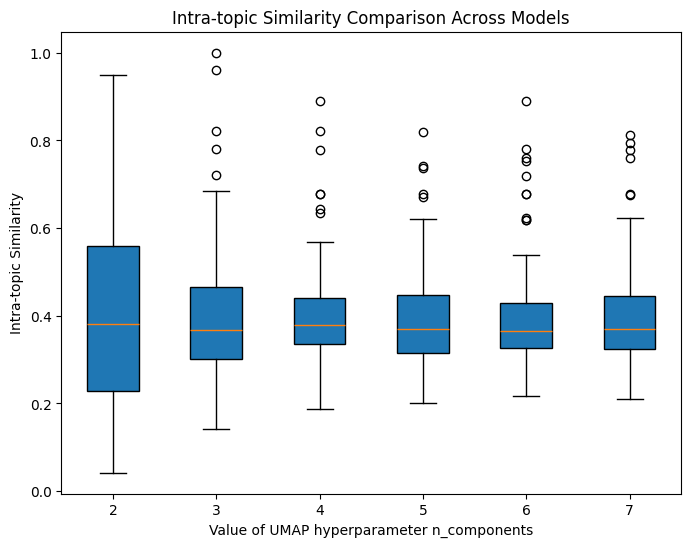

In [57]:
# Print the results
# Prepare data for plotting
data = model_topic_similarities_ncomponents

# Customizing the plot
# Plot boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(data, patch_artist=True)
plt.xticks(range(1, len(data) + 1), n_components_values)  # Dynamically set labels
plt.xlabel("Value of UMAP hyperparameter n_components")
plt.ylabel("Intra-topic Similarity")
plt.title("Intra-topic Similarity Comparison Across Models")
plt.show()

#### 4.1.3. Tuning min_cluster_size

In [60]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
import matplotlib.pyplot as plt
import numpy as np

model_topic_similarities_min_cluster_size = []  # Initialize as a list to store each model's results

for min_cluster_size in min_cluster_size_values:

    
    topic_model = BERTopic(
        # Pipeline models
        embedding_model=embedding_model_st_v1,
        umap_model=UMAP(n_neighbors=40, n_components=4, random_state=42),
        hdbscan_model=HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=True),
        vectorizer_model=CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 2), token_pattern=r'\b[a-zA-Z]{2,}\b'),

        # Hyperparameters
        nr_topics=100,
        top_n_words=10,
        verbose=True
    )

    # Train model
    topics, probs = topic_model.fit_transform(sentences, embeddings)
    topics = topic_model.get_document_info(sentences)["Topic"]
    
    # Compute intra-topic cosine similarity
    intra_topic_similarity = calculate_intra_topic_cosine_similarity(embeddings, topics)
    

    model_topic_similarities_min_cluster_size.append(intra_topic_similarity)

2024-10-31 14:21:40,408 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-10-31 14:22:57,213 - BERTopic - Dimensionality - Completed ✓
2024-10-31 14:22:57,225 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-10-31 14:22:59,153 - BERTopic - Cluster - Completed ✓
2024-10-31 14:22:59,153 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-10-31 14:23:00,060 - BERTopic - Representation - Completed ✓
2024-10-31 14:23:00,060 - BERTopic - Topic reduction - Reducing number of topics
2024-10-31 14:23:00,731 - BERTopic - Topic reduction - Reduced number of topics from 757 to 100
2024-10-31 14:23:01,712 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-10-31 14:24:23,561 - BERTopic - Dimensionality - Completed ✓
2024-10-31 14:24:23,561 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-10-31 14:24:25,377 - BERTopic - Cluster - Completed ✓
2024-10-31 14:24

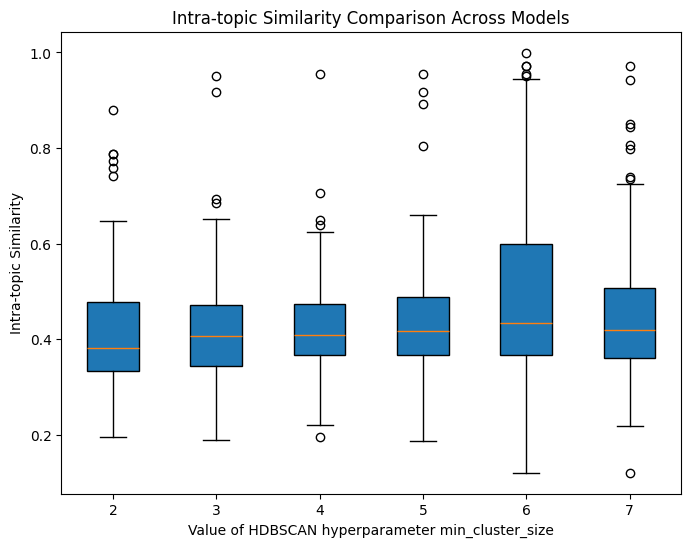

In [61]:
# Print the results
# Prepare data for plotting
data = model_topic_similarities_min_cluster_size

# Customizing the plot
# Plot boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(data, patch_artist=True)
plt.xticks(range(1, len(data) + 1), n_components_values)  # Dynamically set labels
plt.xlabel("Value of HDBSCAN hyperparameter min_cluster_size")
plt.ylabel("Intra-topic Similarity")
plt.title("Intra-topic Similarity Comparison Across Models")
plt.show()

C:\Users\p70092940\AppData\Local\Temp\ipykernel_48892\3662555765.py:20: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



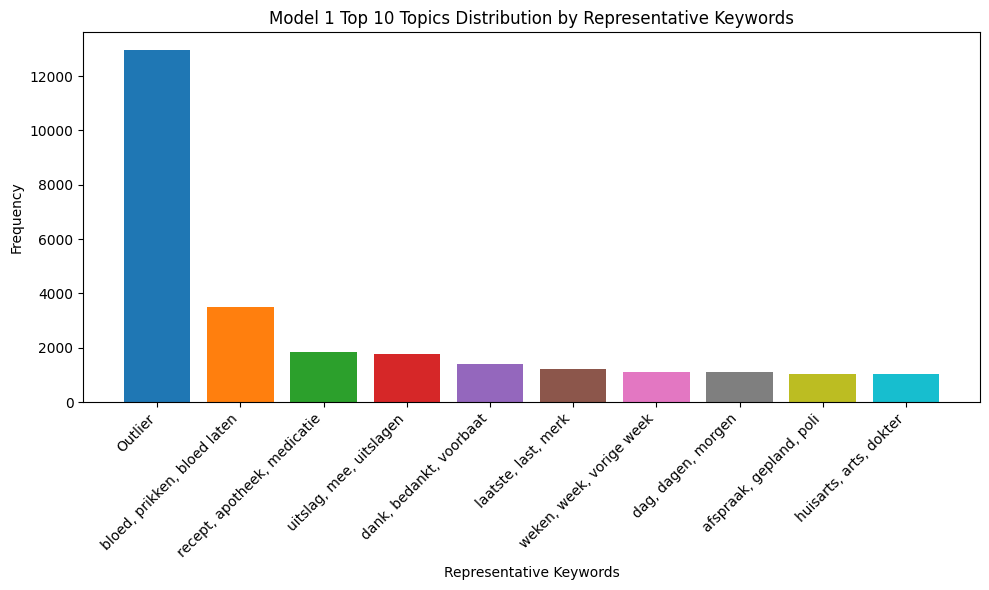

In [14]:

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Get the top 10 topics and their frequencies
freq_df = topic_model.get_topic_freq().head(10)  # Get the top 10 topics
topics = freq_df['Topic'].values
frequencies = freq_df['Count'].values

# Extract the representative keywords for each topic
topic_labels = []
for topic in topics:
    if topic != -1:  # Skip -1, which is usually the "outlier" topic
        words = [word for word, _ in topic_model.get_topic(topic)]
        topic_labels.append(", ".join(words[:3]))  # Join the top 3 words for each topic as a label
    else:
        topic_labels.append("Outlier")  # Label for outliers if they exist

# Generate a color map with unique colors for each bar
colors = cm.get_cmap("tab10", len(topics))(np.arange(len(topics)))

# Plot
plt.figure(figsize=(10, 6))
plt.bar(topic_labels, frequencies, color=colors)
plt.xlabel("Representative Keywords")
plt.ylabel("Frequency")
plt.title("Model 1 Top 10 Topics Distribution by Representative Keywords")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# visualize top 10 topics


In [45]:
doc_info = topic_model.get_document_info(sentences)
doc_info[["Document", "Topic", "Name"]][:30]

,Document,Topic,Name
0,Ik ben 2 weken geleden met spoed opgenomen in het in met verdenking van hartklachten.,5,5_weken_week_vorige week_vorige
1,"Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.",9,9_pijn_buikpijn_pijnlijk_buik
2,Het begon 1 uur na het avondeten.,-1,-1_week_afspraak_recept_dag
3,"Ik had al de hele dag migraine, had dus ook weinig gegeten.",-1,-1_week_afspraak_recept_dag
4,"Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.",9,9_pijn_buikpijn_pijnlijk_buik
5,Op de eerste hulp hebben ze het hart de longen en de bloedvaten onderzocht.,0,0_bloed_prikken_bloed laten_ontlasting
6,er kwamen geen rare dingen uit.,59,59_klachten_klachten klachten_gaat goed_gaten
7,Later op de dag bij het eten van een beschuitje begon het weer.,6,6_dag_dagen_morgen_vandaag
8,Ze hebben een echo van de gal gemaakt ook zonder resultaat.,22,22_klachten_kleine_ontlasting_blijven
9,"Er is nog een aanvullend onderzoek van de slokdarm en de maag gedaan, ook geen resultaat.",15,15_onderzoek_graag_vinden_meedoen


In [39]:
topic_model.visualize_topics()

In [38]:
hierarchical_topics = topic_model.hierarchical_topics(sentences)
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)


100%|██████████| 98/98 [00:00<00:00, 416.44it/s]


In [ ]:
# group the topics into 
topic_other = [33, 38, 120, 57, 116, 128, 41, 134, 111, 118, 
               109, 81, 69, 84, 85, 130, 122, 121, ] # irrelevant sentences, such as "bedankt" and "ik hoor het graag"
topic_symptom = [82, 94, 39, 129, 43, 10, 67, 90] # sentences talking about symptoms, including pain, frequency of toilet use, etc
topic_question = [112, 52, 108, 47, 110, 12, 87, 138, 45] # patients are asking a question or asking for advice 
topic_paperwork = [60, 24, 13, 132] # about forms, documents, letters, questionaires, etc
topic_results = [64, 42, 32, 104] # about lab/home test results
topic_pregnancy = [124, 55]
topic_medication = [135]


In [65]:
pd.set_option("display.max_colwidth", None)
topic_model.get_topic_info(topic=95)

,Topic,Count,Name,Representation,Representative_Docs
0,95,80,95_lang prednisolon_interpreteren_prednisolon hoeveelheid_besproken gaan,"[lang prednisolon, interpreteren, prednisolon hoeveelheid, besproken gaan, vraag gaan, vraag lang, gaat werk, gaat, vraag, gaan]","[We hebben het een en ander besproken, hoe we gaan aanpakken., De vraag nu aan jullie is, hoe nu verder en hoe lang de prednisolon en hoeveelheid er genomen moet worden., De vraag nu aan jullie is, hoe nu verder en hoe lang de prednisolon en hoeveelheid er genomen moet worden.]"


In [83]:
doc_info = topic_model.get_document_info(sentences)
doc_info[doc_info["Document"].index == 10]

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
10,"Ik heb nog altijd last van oprispingen, hoofdpijn en gevoelig rond de maagstreek.",-1,-1_vraag_afspraak_dagen_dag,"[vraag, afspraak, dagen, dag, week, weken, vragen, goed, klachten, last]","[Nog steeds elke dag kylmas gebruiken., Ik ben vorige week maandag tijdens mijn telefonisch consult helemaal vergeten te vragen om een herhaal recept., Het is niet iedere dag hetzelfde.]",vraag - afspraak - dagen - dag - week - weken - vragen - goed - klachten - last,0.0,False


In [15]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.cluster import KMeans
topic_model_2 = BERTopic(

  # Pipeline models
  embedding_model=embedding_model_st_v1,
  umap_model=UMAP(n_neighbors=20, n_components=2, min_dist=0.0, metric='cosine', random_state=42),
  hdbscan_model = KMeans(n_clusters=100),
  vectorizer_model = CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 2), token_pattern=r'\b[a-zA-Z]{2,}\b'),

  # Hyperparameters
  top_n_words=10,
  verbose=True
)

# Train model
topics_2, probs_2 = topic_model_2.fit_transform(sentences, embeddings)

2024-10-29 10:49:50,654 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2024-10-29 10:50:27,797 - BERTopic - Dimensionality - Completed ✓
2024-10-29 10:50:27,797 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-10-29 10:50:28,364 - BERTopic - Cluster - Completed ✓
2024-10-29 10:50:28,388 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-10-29 10:50:29,063 - BERTopic - Representation - Completed ✓


In [50]:
pd.set_option("display.max_colwidth", 500)
topic_info_2 = topic_model_2.get_topic_info()
topic_model_2.generate_topic_labels()

['0_bloed_prikken_bloed laten',
 '1_weken_week_vorige week',
 '2_arts_huisarts_dokter',
 '3_mogelijk_krijgen_stoppen',
 '4_zorgen_denk_idee',
 '5_bloed_prikken_bloed laten',
 '6_recept_apotheek_sturen',
 '7_medicatie_medicijn_medicijnen',
 '8_bloed_slijm_bloed slijm',
 '9_klachten_gaat_beter',
 '10_pijn_buikpijn_hoofdpijn',
 '11_morgen_vandaag_infuus',
 '12_afspraak_gepland_afspraak staan',
 '13_bloed_bloeduitslagen_prikken',
 '14_weken_maanden_maand',
 '15_klachten_rustig_last',
 '16_weten_uitslag_vertellen',
 '17_crohn_ziekte_corona',
 '18_goed_probleem_gaat',
 '19_weten_weet_weet goed',
 '20_mg_daags_tabletten',
 '21_dag_dagen_vandaag',
 '22_vakantie_week_volgende week',
 '23_brief_bericht_mail',
 '24_onderzoek_graag_melden',
 '25_laatste_keer_last',
 '26_eten_toilet_eet',
 '27_test_testen_gedaan',
 '28_voel_gevoel_koorts',
 '29_gehoord_lang_tijd',
 '30_apotheek_recept_recept ontvangen',
 '31_toilet_uur_nacht',
 '32_afspraak_sessie_nieuwe afspraak',
 '33_alvast_bedankt_alvast bedank

In [46]:
doc_info_2 = topic_model_2.get_document_info(sentences)
doc_info_2[["Document", "Topic", "Name"]][:30]

,Document,Topic,Name
0,Ik ben 2 weken geleden met spoed opgenomen in het in met verdenking van hartklachten.,1,1_weken_week_vorige week_vorige
1,"Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.",10,10_pijn_buikpijn_hoofdpijn_pijnlijk
2,Het begon 1 uur na het avondeten.,31,31_toilet_uur_nacht_dag
3,"Ik had al de hele dag migraine, had dus ook weinig gegeten.",21,21_dag_dagen_vandaag_ochtend
4,"Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.",10,10_pijn_buikpijn_hoofdpijn_pijnlijk
5,Op de eerste hulp hebben ze het hart de longen en de bloedvaten onderzocht.,5,5_bloed_prikken_bloed laten_laten prikken
6,er kwamen geen rare dingen uit.,4,4_zorgen_denk_idee_vernomen
7,Later op de dag bij het eten van een beschuitje begon het weer.,21,21_dag_dagen_vandaag_ochtend
8,Ze hebben een echo van de gal gemaakt ook zonder resultaat.,9,9_klachten_gaat_beter_ontlasting
9,"Er is nog een aanvullend onderzoek van de slokdarm en de maag gedaan, ook geen resultaat.",24,24_onderzoek_graag_melden_meedoen


In [42]:
hierarchical_topics_2 = topic_model_2.hierarchical_topics(sentences)
topic_model_2.visualize_hierarchy(hierarchical_topics=hierarchical_topics_2)


100%|██████████| 99/99 [00:00<00:00, 366.41it/s]


C:\Users\p70092940\AppData\Local\Temp\ipykernel_48892\3779094121.py:20: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



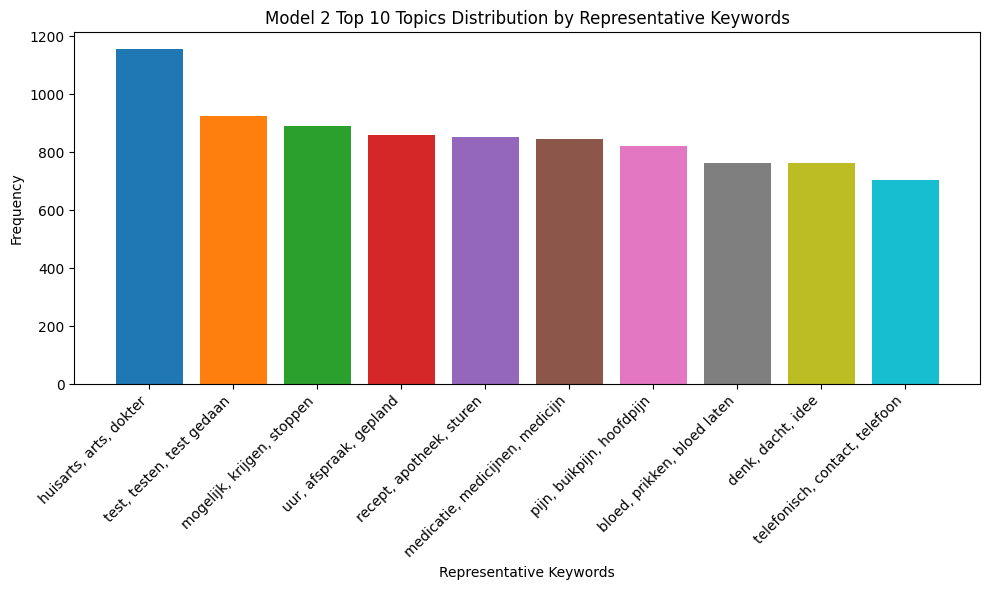

In [17]:

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Get the top 10 topics and their frequencies
freq_df = topic_model_2.get_topic_freq().head(10)  # Get the top 10 topics
topics = freq_df['Topic'].values
frequencies = freq_df['Count'].values

# Extract the representative keywords for each topic
topic_labels = []
for topic in topics:
    if topic != -1:  # Skip -1, which is usually the "outlier" topic
        words = [word for word, _ in topic_model_2.get_topic(topic)]
        topic_labels.append(", ".join(words[:3]))  # Join the top 3 words for each topic as a label
    else:
        topic_labels.append("Outlier")  # Label for outliers if they exist

# Generate a color map with unique colors for each bar
colors = cm.get_cmap("tab10", len(topics))(np.arange(len(topics)))

# Plot
plt.figure(figsize=(10, 6))
plt.bar(topic_labels, frequencies, color=colors)
plt.xlabel("Representative Keywords")
plt.ylabel("Frequency")
plt.title("Model 2 Top 10 Topics Distribution by Representative Keywords")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
